In [2]:
!pip install xgboost
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

In [3]:
train_df = pd.read_csv('train_processed.csv')
val_df = pd.read_csv('val_processed.csv')
test_df = pd.read_csv('test_processed.csv')
w_train = pd.read_csv('w_train.csv').squeeze()
w_val = pd.read_csv('w_val.csv').squeeze()
w_test = pd.read_csv('w_test.csv').squeeze()

X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_val = val_df.drop(columns=['label'])
y_val = val_df['label']
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

In [4]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                     eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train, sample_weight=w_train)

y_prob_xgb = xgb.predict_proba(X_val)[:, 1]

for thresh in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45]:
    y_pred = (y_prob_xgb >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.2: F1=0.3522
Threshold 0.25: F1=0.3781
Threshold 0.3: F1=0.4012
Threshold 0.35: F1=0.4198
Threshold 0.4: F1=0.4401
Threshold 0.45: F1=0.4575


In [5]:
print(y_prob_xgb[:20])
print(y_prob_xgb.min(), y_prob_xgb.max())

[1.5617552e-05 2.7784750e-05 2.0331893e-02 3.2161435e-05 2.7784750e-05
 2.7784750e-05 3.2161435e-05 3.2161435e-05 3.2161435e-05 5.2805048e-01
 3.2960537e-01 6.4373075e-04 3.6720834e-05 9.9893886e-01 2.7948766e-04
 1.5617552e-05 6.0572783e-03 1.1016901e-02 3.3974625e-02 3.2161435e-05]
3.151933e-34 0.99999905


In [6]:
print(X_train.dtypes)
print(X_train.isnull().sum())

age                                                 float64
wage per hour                                       float64
capital gains                                       float64
capital losses                                      float64
dividends from stocks                               float64
                                                     ...   
education_High school graduate                        int64
education_Less than 1st grade                         int64
education_Masters degree(MA MS MEng MEd MSW MBA)      int64
education_Prof school degree (MD DDS DVM LLB JD)      int64
education_Some college but no degree                  int64
Length: 108, dtype: object
age                                                 0
wage per hour                                       0
capital gains                                       0
capital losses                                      0
dividends from stocks                               0
                                           

In [7]:
print(f"Class 0 count: {len(y_train[y_train==0])}")
print(f"Class 1 count: {len(y_train[y_train==1])}")
print(f"scale_pos_weight: {scale_pos_weight}")
print(y_train.value_counts())

Class 0 count: 128738
Class 1 count: 8667
scale_pos_weight: 14.853813314872506
label
0    128738
1      8667
Name: count, dtype: int64


In [8]:
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                     eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)  # no sample_weight

y_prob_xgb = xgb.predict_proba(X_val)[:, 1]
print(y_prob_xgb.min(), y_prob_xgb.max())

1.9973604e-06 0.9999057


In [9]:
for thresh in [0.5, 0.6, 0.7, 0.8, 0.82, 0.85, 0.9]:
    y_pred = (y_prob_xgb >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.5: F1=0.4869
Threshold 0.6: F1=0.5280
Threshold 0.7: F1=0.5668
Threshold 0.8: F1=0.6073
Threshold 0.82: F1=0.6121
Threshold 0.85: F1=0.6142
Threshold 0.9: F1=0.6053


In [10]:
for thresh in [0.83, 0.84, 0.85, 0.86, 0.87, 0.88]:
    y_pred = (y_prob_xgb >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.83: F1=0.6131
Threshold 0.84: F1=0.6132
Threshold 0.85: F1=0.6142
Threshold 0.86: F1=0.6135
Threshold 0.87: F1=0.6144
Threshold 0.88: F1=0.6162


              precision    recall  f1-score   support

           0       0.97      0.98      0.97     27587
           1       0.63      0.60      0.61      1857

    accuracy                           0.95     29444
   macro avg       0.80      0.79      0.79     29444
weighted avg       0.95      0.95      0.95     29444

ROC-AUC: 0.9511253564114852

Of every 100 flagged: 63 are genuine high earners
Model catches 60% of all actual high earners


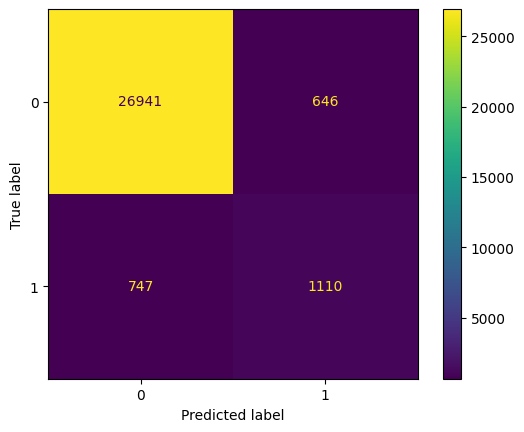

In [16]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_xgb_final = (y_prob_xgb >= 0.87).astype(int)
print(classification_report(y_val, y_pred_xgb_final))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_xgb))

cm = confusion_matrix(y_val, y_pred_xgb_final)
ConfusionMatrixDisplay(cm).plot()

tn, fp, fn, tp = cm.ravel()
print(f"\nOf every 100 flagged: {tp/(tp+fp)*100:.0f} are genuine high earners")
print(f"Model catches {tp/(tp+fn)*100:.0f}% of all actual high earners")

In [17]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_tuned = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                  eval_metric='logloss', verbosity=0),
    params,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

xgb_tuned.fit(X_train, y_train)
print(f"Best params: {xgb_tuned.best_params_}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [20]:
best_xgb = xgb_tuned.best_estimator_

y_prob_xgb_tuned = best_xgb.predict_proba(X_val)[:, 1]

for thresh in [0.80, 0.82, 0.85, 0.87, 0.90]:
    y_pred = (y_prob_xgb_tuned >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.8: F1=0.6098
Threshold 0.82: F1=0.6116
Threshold 0.85: F1=0.6121
Threshold 0.87: F1=0.6101
Threshold 0.9: F1=0.5959


              precision    recall  f1-score   support

           0       0.97      0.98      0.97     27587
           1       0.62      0.60      0.61      1857

    accuracy                           0.95     29444
   macro avg       0.80      0.79      0.79     29444
weighted avg       0.95      0.95      0.95     29444

ROC-AUC: 0.9491858029248595

Of every 100 flagged: 62 are genuine high earners
Model catches 60% of all actual high earners


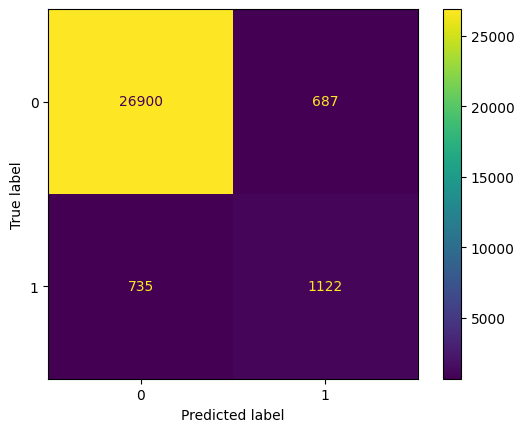

In [19]:
y_pred_xgb_tuned_final = (y_prob_xgb_tuned >= 0.85).astype(int)
print(classification_report(y_val, y_pred_xgb_tuned_final))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_xgb_tuned))

cm = confusion_matrix(y_val, y_pred_xgb_tuned_final)
ConfusionMatrixDisplay(cm).plot()

tn, fp, fn, tp = cm.ravel()
print(f"\nOf every 100 flagged: {tp/(tp+fp)*100:.0f} are genuine high earners")
print(f"Model catches {tp/(tp+fn)*100:.0f}% of all actual high earners")

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_best = (y_prob >= 0.82).astype(int)
cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
print(confusion_matrix(y_val, y_pred_best))